# Virtual IAI office

This simulation showcases a Tortugabot navigating and scanning IAI office environment using LiDAR sensor and camera. An environment for teaching sensors and navigation modules.

**Environment**: [IAI office](https://github.com/code-iai/iai_office_sim)

**Robot**: [Tortugabot](https://github.com/code-iai/tortugabot)

**Simulator**: [Gazebo](https://classic.gazebosim.org/)

---

<button data-commandlinker-command="notebook:run-all-cells" class="jupyter-button" style="color: #fff;font-size:1rem; background-color: #1976d2;">Run All Code</button>
<button data-commandlinker-command="notebook:interrupt-kernel" class="jupyter-button" style="font-size:1rem;">Stop All</button>

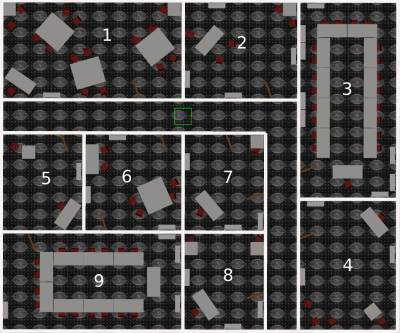

## Open virtual display

In [1]:
%run ../utils.py
display_desktop(anchor='split-right')
sleep(3)

## Launch Simulation

You will see the Rviz window popup visualize the sensor data in red dots and a camera view on the left bottom.

In [2]:
from psutil import Popen
import os
import subprocess

Popen(['/bin/bash', '-c',
        '''
        export OFFICE_DIR=/home/jovyan/ros2_ws/src/iai_office_sim
        ros2 launch nav2_bringup tb3_simulation_launch.py \
            use_rviz:=True \
            headless:=True \
            slam:=True \
            map:=$OFFICE_DIR/maps/map.yaml \
            rviz_config_file:=$PWD/nav2.rviz \
            world:=$OFFICE_DIR/worlds/office_sim_WS15.world
        '''],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL)

psutil.Popen(pid=30794, name='bash', status='running', started='12:35:50')

## Robot steering

The following code will display two slider to control the robot.

You can move the robot around to explore the simulation environment.

In [3]:
velocity_publisher = VelocityPublisher()
robot_steering(velocity_publisher)

# Wait for simulator ready
sleep(3)

#### Robot Steering:

Box(children=(FloatSlider(value=0.0, description='Moving', max=0.5, min=-0.5, orientation='vertical', step=0.0…

## Navigation example

### 1. Scan the environment

In [1]:
import rclpy
from rclpy.action import ActionClient
from rclpy.node import Node
from nav2_msgs.action import NavigateToPose
from geometry_msgs.msg import PoseStamped
from threading import Event
from time import sleep

class Nav2Client(Node):
    def __init__(self):
        super().__init__('nav2_client')
        self._action_client = ActionClient(self, NavigateToPose, 'navigate_to_pose')
        self.feedback = ''
        self._done_event = Event()

    def send_goal(self, x, y):
        self._done_event.clear()

        goal_msg = NavigateToPose.Goal()
        goal_msg.pose.header.frame_id = 'map'
        goal_msg.pose.header.stamp = self.get_clock().now().to_msg()
        goal_msg.pose.pose.position.x = float(x)
        goal_msg.pose.pose.position.y = float(y)
        goal_msg.pose.pose.orientation.w = 1.0

        self._action_client.wait_for_server()
        self.get_logger().info(f'Sending goal to ({x}, {y})')

        send_goal_future = self._action_client.send_goal_async(
            goal_msg,
            feedback_callback=self.feedback_callback
        )
        send_goal_future.add_done_callback(self.goal_response_callback)

        # Spin until goal is done
        while not self._done_event.is_set():
            rclpy.spin_once(self, timeout_sec=0.1)
        return self.feedback

    def goal_response_callback(self, future):
        self._goal_handle = future.result()
        if not self._goal_handle.accepted:
            self.get_logger().warn('Goal was rejected!')
            self._done_event.set()
            self.feedback = "REJECTED"
            return

        self.get_logger().info('Goal accepted')
        self._goal_handle.get_result_async().add_done_callback(self.result_callback)

    def feedback_callback(self, feedback_msg):
        feedback = feedback_msg.feedback
        # self.get_logger().info(f'Distance remaining: {feedback.distance_remaining:.2f} m')

    def result_callback(self, future):
        status = future.result().status
        status_map = {
            4: "SUCCEEDED",
            6: "ABORTED"
        }
        self.feedback = status_map.get(status, f"UNKNOWN")
        self.get_logger().info(f'Goal result: {self.feedback}')
        self._done_event.set()

if not rclpy.ok():
    rclpy.init()

nav_cli = Nav2Client()

In [2]:
# A hardcored scanning waypoints
waypoints = [
    (0, 0), (-4, 4), (-8, 4),
    (0, 0), (6, 0), (4, 4),
    (6, 0), (6, -4), (10, 4),
    (6, -4), (6, -8), (10, -10), 
    (6, -10), (3, -11),
    (3, -5),
    (-8, 0), (-8, -4),
    (-10, -12), (-1, -12), 
    (0, 0)
]

# Try to reach each waypoint, retry up to 3 times if failed
for idx, (x, y) in enumerate(waypoints):
    max_attempts = 5
    attempt = 0
    wait_time = 2
    while attempt < max_attempts:
        result = nav_cli.send_goal(x, y)
        if result == 'SUCCEEDED':
            break
        else:
            print(f"Attempt {attempt + 1} failed with result: {result}")
            sleep(wait_time)
            attempt += 1
    else:
        print(f"⚠️ Failed to reach waypoint ({x}, {y}) after {max_attempts} attempts.")

[INFO] [1750942357.106984383] [nav2_client]: Sending goal to (6, -4)
[INFO] [1750942357.111831325] [nav2_client]: Goal accepted
[INFO] [1750942364.171571419] [nav2_client]: Goal result: SUCCEEDED
[INFO] [1750942364.174604038] [nav2_client]: Sending goal to (6, -8)
[INFO] [1750942364.177972445] [nav2_client]: Goal accepted
[INFO] [1750942383.238801718] [nav2_client]: Goal result: SUCCEEDED
[INFO] [1750942383.241823117] [nav2_client]: Sending goal to (10, -10)
[INFO] [1750942383.245032794] [nav2_client]: Goal accepted
[INFO] [1750942402.805919666] [nav2_client]: Goal result: SUCCEEDED
[INFO] [1750942402.809012841] [nav2_client]: Sending goal to (6, -10)
[INFO] [1750942402.812352795] [nav2_client]: Goal accepted
[INFO] [1750942431.023271568] [nav2_client]: Goal result: SUCCEEDED
[INFO] [1750942431.026354898] [nav2_client]: Sending goal to (3, -11)
[INFO] [1750942431.029966652] [nav2_client]: Goal accepted
[INFO] [1750942450.190524164] [nav2_client]: Goal result: SUCCEEDED
[INFO] [17509424

**Save the map**

```bash
ros2 service call /slam_toolbox/save_map slam_toolbox/srv/SaveMap "name:
    data: 'my_map'"
```

You will find two files `my_map.pgm` and `my_map.yaml`.

In [ ]:
%%bash
ros2 service call /slam_toolbox/save_map slam_toolbox/srv/SaveMap "name:
    data: 'my_map'"

### 2. Navigate to any position

After the scanning, test long distance path planning

In [ ]:
# From room 1 => room 9 => room 4
nav_cli.send_goal(-8, 4)
nav_cli.send_goal(-1, -12)
nav_cli.send_goal(10, -10)

[INFO] [1750942868.814854655] [nav2_client]: Sending goal to (-8, 4)
[INFO] [1750942868.819611733] [nav2_client]: Goal accepted
[INFO] [1750942919.879286617] [nav2_client]: Goal result: SUCCEEDED
[INFO] [1750942919.882484495] [nav2_client]: Sending goal to (-1, -12)
[INFO] [1750942919.886308366] [nav2_client]: Goal accepted
